In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Libraries for data analysis

In [4]:
df = pd.read_csv(r"C:\Users\malak\OneDrive\Desktop\Data Analytics Python\Lab Project 7th\2015.csv")
df.head()


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


#Loading dataset

In [5]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory usage: 14.9 KB


#Inspect size, columns, data types

In [6]:
df.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

#checking missing values

In [7]:
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [8]:
print('Unique Countries:', df['Country'].nunique())
print('Unique Regions: ', df['Region'].nunique())
print('Regions present:')
print(df['Region'].value_counts())

Unique Countries: 158
Unique Regions:  10
Regions present:
Region
Sub-Saharan Africa                 40
Central and Eastern Europe         29
Latin America and Caribbean        22
Western Europe                     21
Middle East and Northern Africa    20
Southeastern Asia                   9
Southern Asia                       7
Eastern Asia                        6
North America                       2
Australia and New Zealand           2
Name: count, dtype: int64


In [22]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# Drop duplicates if any
df = df.drop_duplicates()
print(f'Shape after dropping duplicates: {df.shape}')

Duplicate rows: 0
Shape after dropping duplicates: (158, 12)


#Descriptive analysis

In [9]:
corr=df.corr(numeric_only=True)
corr

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
Happiness Rank,1.000000,-0.992105,0.158516,-0.785267,-0.733644,-0.735613,-0.556886,-0.372315,-0.160142,-0.521999
Happiness Score,-0.992105,1.000000,-0.177254,0.780966,0.740605,0.724200,0.568211,0.395199,0.180319,0.530474
Standard Error,0.158516,-0.177254,1.000000,-0.217651,-0.120728,-0.310287,-0.129773,-0.178325,-0.088439,0.083981
Economy (GDP per Capita),-0.785267,0.780966,-0.217651,1.000000,0.645299,0.816478,0.370300,0.307885,-0.010465,0.040059
Family,-0.733644,0.740605,-0.120728,0.645299,1.000000,0.531104,0.441518,0.205605,0.087513,0.148117
Health (Life Expectancy),-0.735613,0.724200,-0.310287,0.816478,0.531104,1.000000,0.360477,0.248335,0.108335,0.018979
Freedom,-0.556886,0.568211,-0.129773,0.370300,0.441518,0.360477,1.000000,0.493524,0.373916,0.062783
Trust (Government Corruption),-0.372315,0.395199,-0.178325,0.307885,0.205605,0.248335,0.493524,1.000000,0.276123,-0.033105
Generosity,-0.160142,0.180319,-0.088439,-0.010465,0.087513,0.108335,0.373916,0.276123,1.000000,-0.101301
Dystopia Residual,-0.521999,0.530474,0.083981,0.040059,0.148117,0.018979,0.062783,-0.033105,-0.101301,1.000000


#Correlation between different variables 

In [10]:
corr["Happiness Score"].sort_values(ascending=False)

Happiness Score                  1.000000
Economy (GDP per Capita)         0.780966
Family                           0.740605
Health (Life Expectancy)         0.724200
Freedom                          0.568211
Dystopia Residual                0.530474
Trust (Government Corruption)    0.395199
Generosity                       0.180319
Standard Error                  -0.177254
Happiness Rank                  -0.992105
Name: Happiness Score, dtype: float64

#correlation between variables and happiness score

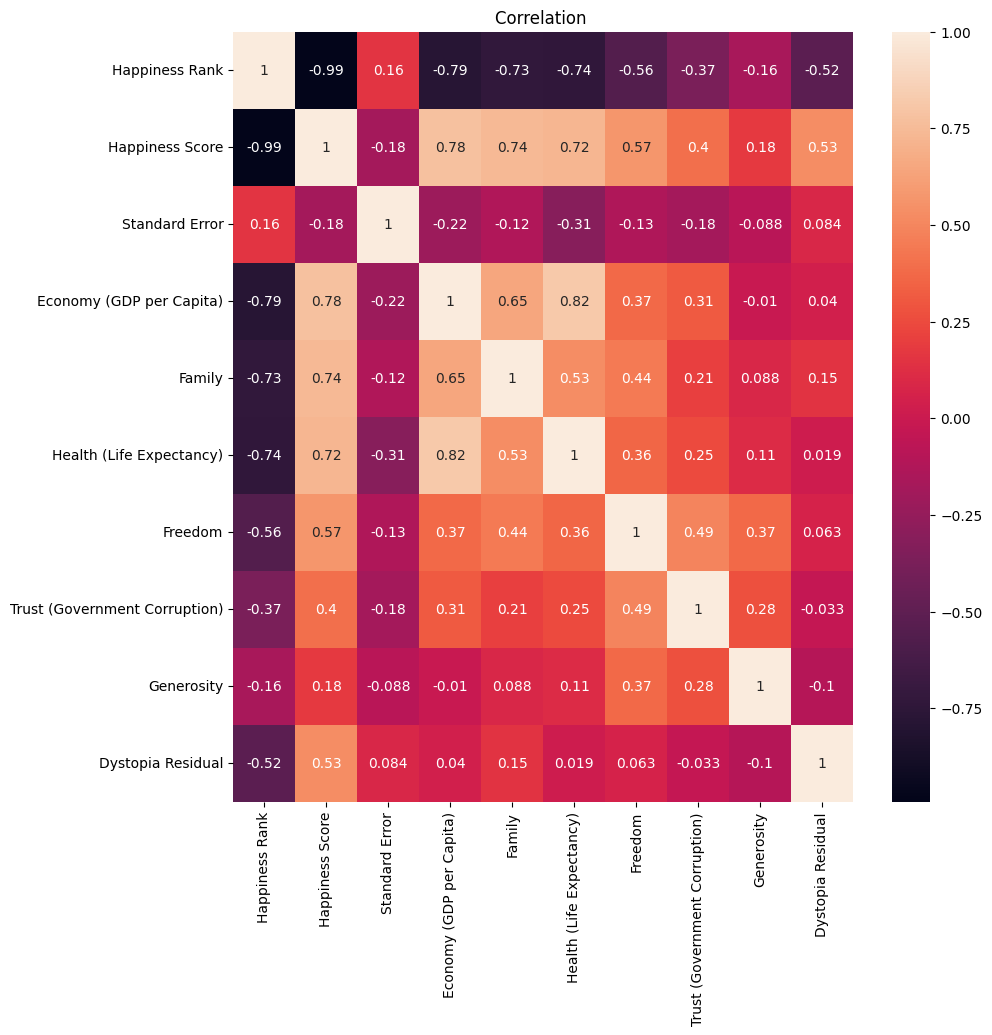

In [11]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True)
plt.title("Correlation ")
plt.show()


#Visualization of relationships between variables

In [12]:
regionAvg = df.groupby("Region")["Happiness Score"].mean()
regionAvg

Region
Australia and New Zealand          7.285000
Central and Eastern Europe         5.332931
Eastern Asia                       5.626167
Latin America and Caribbean        6.144682
Middle East and Northern Africa    5.406900
North America                      7.273000
Southeastern Asia                  5.317444
Southern Asia                      4.580857
Sub-Saharan Africa                 4.202800
Western Europe                     6.689619
Name: Happiness Score, dtype: float64

#Groupby to compare average happiness across regions

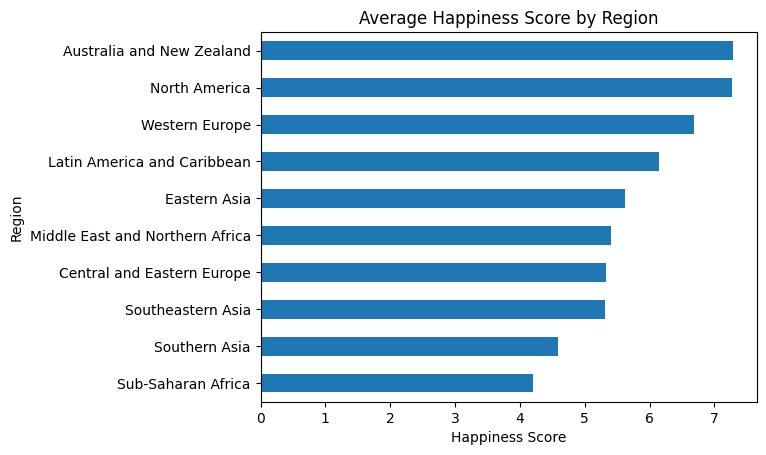

In [13]:
regionAvg.sort_values().plot(kind="barh")

plt.title("Average Happiness Score by Region")
plt.xlabel("Happiness Score")

plt.show()

#Comparing regions visually

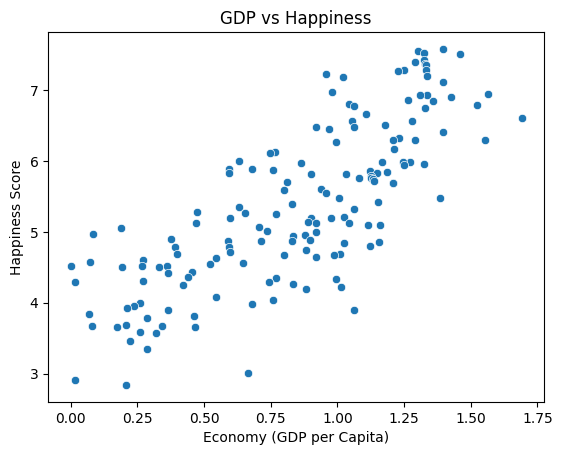

In [14]:
sns.scatterplot(x="Economy (GDP per Capita)", y="Happiness Score", data=df)

plt.title("GDP vs Happiness")

plt.show()

#Relationship between GDP and happiness

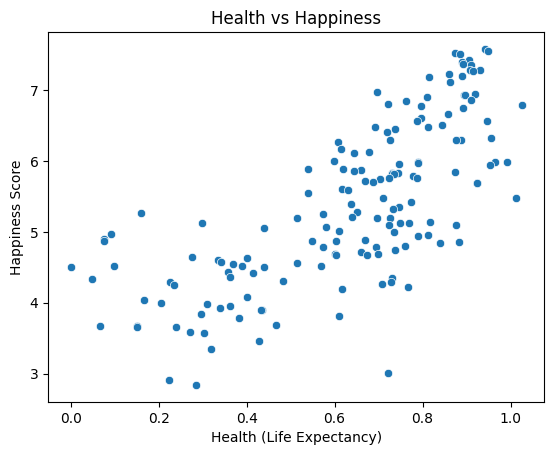

In [15]:
sns.scatterplot(x="Health (Life Expectancy)", y="Happiness Score", data=df)

plt.title("Health vs Happiness")

plt.show()

#Relationship between health and happiness

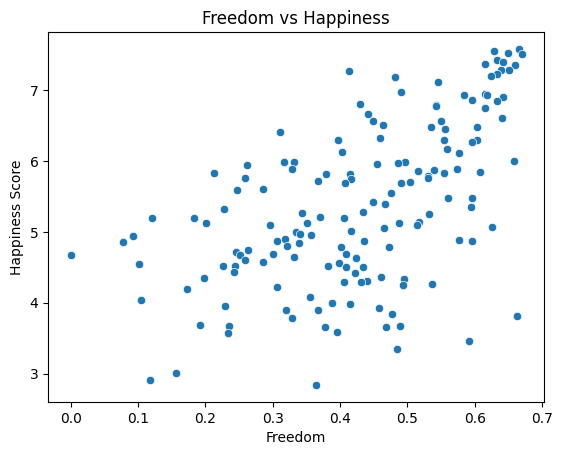

In [16]:
sns.scatterplot(x="Freedom", y="Happiness Score", data=df)

plt.title("Freedom vs Happiness")

plt.show()

#Relationship between freedom and happiness

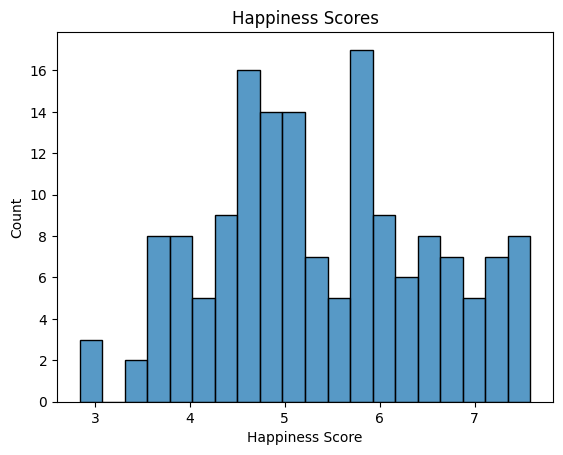

In [17]:
sns.histplot(df["Happiness Score"], bins=20)

plt.title("Happiness Scores")

plt.show()

#Distribution of happiness values

In [18]:
df.sort_values("Happiness Score", ascending=False).head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


#Top 5 Happy Countries 

In [19]:
df.sort_values("Happiness Score").head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
157,Togo,Sub-Saharan Africa,158,2.839,0.06727,0.20868,0.13995,0.28443,0.36453,0.10731,0.16681,1.56726
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042


#Least 5 Happy countries

In [20]:
df.groupby("Region")[["Economy (GDP per Capita)", "Health (Life Expectancy)","Freedom"]].mean()

,Economy (GDP per Capita),Health (Life Expectancy),Freedom
Region,,,
Australia and New Zealand,1.291880,0.919965,0.645310
Central and Eastern Europe,0.942438,0.718774,0.358269
Eastern Asia,1.151780,0.877388,0.462490
Latin America and Caribbean,0.876815,0.703870,0.501740
Middle East and Northern Africa,1.066974,0.705615,0.361751
North America,1.360400,0.883710,0.589505
Southeastern Asia,0.789054,0.677357,0.557104
Southern Asia,0.560486,0.540830,0.373337
Sub-Saharan Africa,0.380473,0.282332,0.365944


#Comparing GDP and health and freedom across regions

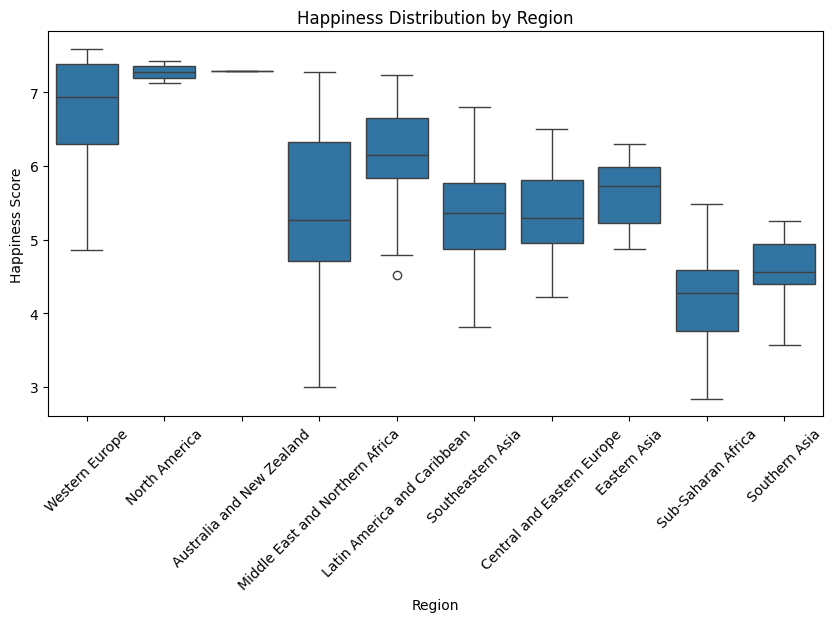

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Region", y="Happiness Score", data=df)

plt.xticks(rotation=45)
plt.title("Happiness Distribution by Region")

plt.show()

#Box plot to show distribution of happiness over regions

What i discovered from the Dataset:

- In this project I worked on the World Happiness Report 2015 dataset to see
what affects happiness in different countries

- I explored the dataset (shape, columns, data types, missing values) and
found that the data is clean

- I used descriptive statistics to understand how happiness scores are
distributed

- I used correlation to see which factors affect happiness the most, and I found
that GDP and health have the strongest impact

- I used scatter plots to visualize relationships between happiness and factors
like GDP, health, and freedom

- I compared regions using groupby, and found that Western Europe has the
highest happiness levels

- I also used a boxplot to see how happiness varies across regions

- Overall countries with higher GDP, better health, and more freedom tend to be happier